# FDA 이상사례 데이터 - ATC R코드, F군(비강 스테로이드/Fluticasone) 인사이트 분석

전체 FDA 이상사례 보고 데이터 중 ATC 1단계 코드 R(Respiratory system, 호흡기계) 의약품을
항히스타민제 단일(A) / 수면유도 복합제(D) / 비충혈제거제 단일(C) / 진해거담제(B) /
항히스타민+비충혈제거제 복합감기약(E) / 흡입형(비강) 스테로이드(F) / 소아 감기약 복합제(G) / 기타(H)로
재분류했을 때, 이 중 F군(비강 스테로이드, 도출_ATC코드 == "R01AD08", 성분 Fluticasone propionate/furoate
nasal spray)에 대해서만 아래 항목을 분석합니다.

F군은 40건(전체 이미지 기준 2.6%)으로 다른 노트북(리도카인 155건, 디클로페낙 260건)보다 표본이 훨씬 작습니다.
그래서 이번 노트북은 두 갈래로 구성됩니다.

- 데이터로 답할 수 있는 부분은 통계 검정과 함께 분석하되, 표본이 작아 검정력이 낮다는 한계를 매번 명시합니다.
- 데이터만으로는 근거가 약하거나 건수가 너무 적은 위험 신호(소아 성장 저하, 비중격 천공, 녹내장/백내장,
  약물 상호작용에 의한 전신 흡수 부작용 등)는 별도 섹션(13번)에서 관련 의학 문헌을 찾아 출처와 함께 보완합니다.

1. F군 정의 확인 (건수 검증)
2. 인체 특성 (연령.성별)
3. 심각도 (사망.입원.생명위협.장애.회복여부)
4. 병용 약물 수 (다제복용)
5. 투약 사유(적응증)
6. 이상반응 유형
7. 전체 반응(reactions) 분해
8. 전신 흡수 위험 신호 - 부신기능저하/쿠싱증후군 (데이터 + 문헌)
9. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향
10. 심각도(serious)와 인체특성·병용약물의 관계 (표본 한계 포함)
11. 숫자형 변수 상관관계 히트맵 (표본 한계 포함)
12. 같은 ATC코드(R) 내 비교 - 비강 스테로이드 vs 경구 항히스타민제
13. 문헌 기반 보완 분석 - 데이터에 없거나 건수가 너무 적은 위험 신호
14. 종합 인사이트 요약

비교 기준선은 F군을 제외한 전체 데이터(나머지 전체, Rest)로 설정합니다.

(※ 시계열/브랜드·제조사 기반 분석은 제외했습니다 - quarter는 FDA 보고서 "접수일" 기준이라 실제 발생 시점을
반영하지 못하고, 브랜드·제조사별 보고 건수/비율도 실사용량 등 노출 분모가 없어 위험도 비교로 쓰기 어렵기 때문입니다.)

In [1]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# 한글 폰트 설정
candidates = ["AppleGothic", "Apple SD Gothic Neo", "NanumGothic", "Malgun Gothic"]
available = {f.name for f in fm.fontManager.ttflist}
kfont = next((c for c in candidates if c in available), None)
if kfont:
    plt.rcParams["font.family"] = kfont
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["figure.dpi"] = 110

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

In [2]:
# 색상 팔레트 (범주형 고정 순서 + 상태색)
C1_BLUE, C2_AQUA, C3_YELLOW, C4_GREEN = "#2a78d6", "#1baf7a", "#eda100", "#008300"
C5_VIOLET, C6_RED, C7_MAGENTA, C8_ORANGE = "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"
MUTED, GRID, INK, INK2 = "#898781", "#e1e0d9", "#0b0b0b", "#52514e"
STATUS_CRIT = "#d03b3b"

def style_ax(ax, title=None, xlabel=None, ylabel=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(GRID)
    ax.spines["bottom"].set_color("#c3c2b7")
    ax.tick_params(colors=INK2, labelsize=9)
    ax.yaxis.grid(True, color=GRID, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    if title:
        ax.set_title(title, fontsize=12, color=INK, fontweight="bold", pad=10)
    if xlabel:
        ax.set_xlabel(xlabel, fontsize=9.5, color=INK2)
    if ylabel:
        ax.set_ylabel(ylabel, fontsize=9.5, color=INK2)

def p_str(x):
    return "p < 0.001" if x < 0.001 else "p = {:.3f}".format(x)

## 데이터 로드 및 F군(비강 스테로이드) 정의

In [3]:
DATA_PATH = "FDA_adverse_events_final_참조표병합.csv"  # 노트북과 같은 폴더에 위치

df = pd.read_csv(DATA_PATH, low_memory=False)
df["age_num"] = pd.to_numeric(df["patient_age_years"], errors="coerce")
df["weight_num"] = pd.to_numeric(df["patient_weight_kg"], errors="coerce")

# 코드 R(호흡기계) 전체 및 세부 그룹
r_all = df[df["도출_ATC코드"].astype(str).str.startswith("R")].copy()
print("코드 R(호흡기계) 전체 건수:", f"{len(r_all):,}")
print(r_all["도출_ATC코드"].value_counts())
print()

# F군 = 비강 스테로이드(Fluticasone propionate/furoate nasal spray), ATC 도출코드 R01AD08
is_F = df["도출_ATC코드"] == "R01AD08"
f = df[is_F].copy()
rest = df[~is_F].copy()

print(f"F군(비강 스테로이드) 건수: {len(f):,}  (참고: 제공 이미지 기준 40건, 2.6% - 정확히 일치)")
print(f"F군 비중(코드 R 내): {len(f)/len(r_all)*100:.1f}%")
print(f"F군 대표 성분: {f['참조_영문성분명'].unique()}")
print(f"나머지 전체(Rest) 건수: {len(rest):,}")
print()
f_serious_pct = (f['serious']=='Yes').mean()*100
rest_serious_pct = (rest['serious']=='Yes').mean()*100
print(f"F군 심각(serious) 비율: {f_serious_pct:.1f}%  (n=40 중 27건)")
print(f"F군 사망(fatal) 비율: {f['is_fatal'].mean()*100:.1f}%  (n=40 중 2건)")
print(f"나머지 전체(Rest) 심각 비율: {rest_serious_pct:.1f}%")
print()
print("주의: F군은 n=40으로 표본이 작아, 이후 통계 검정 다수가 유의성에 도달하지 못합니다.")
print("      유의하지 않은 결과도 '차이가 없다'가 아니라 '이 표본 크기로는 판단하기 어렵다'로 해석해야 합니다.")

코드 R(호흡기계) 전체 건수: 1,290
도출_ATC코드
R06AE07    355
R06AX26    246
R06AA02    169
R05CA03    104
R06AE09     96
R01BA02     87
R06AX13     79
R01AD08     40
R06AA09     33
R01AA04     26
R05DA09     18
R01AA05      9
R06AB04      8
R01AD05      6
R06AE05      4
R01AC01      4
R01AD12      3
R06AA52      2
R01AA07      1
Name: count, dtype: int64

F군(비강 스테로이드) 건수: 40  (참고: 제공 이미지 기준 40건, 2.6% - 정확히 일치)
F군 비중(코드 R 내): 3.1%
F군 대표 성분: ['Fluticasone propionate/furoate (nasal spray)']
나머지 전체(Rest) 건수: 18,233

F군 심각(serious) 비율: 67.5%  (n=40 중 27건)
F군 사망(fatal) 비율: 5.0%  (n=40 중 2건)
나머지 전체(Rest) 심각 비율: 85.6%

주의: F군은 n=40으로 표본이 작아, 이후 통계 검정 다수가 유의성에 도달하지 못합니다.
      유의하지 않은 결과도 '차이가 없다'가 아니라 '이 표본 크기로는 판단하기 어렵다'로 해석해야 합니다.


## 1. 인체 특성 (연령 · 성별)

In [4]:
# 연령 히스토그램/연령대 비교 차트는 생략 - n=40(연령 확인 가능 20건)으로는 분포 형태 자체가
# 의미 있는 패턴을 보여주지 못해 시각화 대신 검정 결과만 수치로 확인
age_f = f["age_num"].dropna()
age_rest = rest["age_num"].dropna()

u_age, p_age = stats.mannwhitneyu(age_f, age_rest, alternative="two-sided")
print(f"[연령] Mann-Whitney U 검정: U={u_age:.0f}, {p_str(p_age)}  (F군 중앙값 {age_f.median():.0f}세 vs Rest 중앙값 {age_rest.median():.0f}세)")
print("  → 유의하지 않음 - F군(n=40, 연령 확인 가능 20건)만으로는 나머지 전체와 연령 분포 차이를 확정할 수 없음")
print()
f_unknown_age = (f['age_group']=='Unknown').mean()*100
rest_unknown_age = (rest['age_group']=='Unknown').mean()*100
print(f"[연령 결측] F군 {f_unknown_age:.1f}%(20/40) vs Rest {rest_unknown_age:.1f}% - F군 연령 결측이 훨씬 높음")

[연령] Mann-Whitney U 검정: U=133028, p = 0.859  (F군 중앙값 56세 vs Rest 중앙값 60세)
  → 유의하지 않음 - F군(n=40, 연령 확인 가능 20건)만으로는 나머지 전체와 연령 분포 차이를 확정할 수 없음

[연령 결측] F군 50.0%(20/40) vs Rest 28.7% - F군 연령 결측이 훨씬 높음


In [5]:
# 성별 비교 차트도 생략 - n=40으로는 나머지 전체(1.8만여 건)와의 비율 차이가 통계적으로 뒷받침되지 않음
print(f["patient_sex"].value_counts())
print("→ F군은 남녀 비율이 35%로 동률(미상 30%) - 나머지 전체(여성 49.8%)보다 여성 비중이 낮게 보이지만")
print("  n=40으로는 이 차이가 실제인지 우연인지 판단하기 어려움")
print()

w_f = f['weight_num'].dropna()
print(f"[체중] 결측 아닌 값: {len(w_f)}/{len(f)}건뿐 - 분석에 사용하기엔 표본이 너무 작아 생략")

patient_sex
Male       14
Female     14
Unknown    12
Name: count, dtype: int64
→ F군은 남녀 비율이 35%로 동률(미상 30%) - 나머지 전체(여성 49.8%)보다 여성 비중이 낮게 보이지만
  n=40으로는 이 차이가 실제인지 우연인지 판단하기 어려움

[체중] 결측 아닌 값: 8/40건뿐 - 분석에 사용하기엔 표본이 너무 작아 생략


## 2. 심각도 (사망·입원·생명위협·장애·회복여부)

In [6]:
sev_cols = ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling", "patient_recovered"]
sev_labels = ["사망", "입원", "생명위협", "장애", "회복됨"]

# 심각도 지표 비교 차트는 생략 - 아래 Chi-square 검정 전부 유의하지 않아(p>0.05) 막대그래프로
# 그려도 표본오차 범위 안의 흔들림을 실제 차이처럼 보이게 할 위험이 있음
f_rate = [f[col].mean() * 100 for col in sev_cols]
rest_rate = [rest[col].mean() * 100 for col in sev_cols]

print("[F군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표, n=40이라 검정력 낮음에 유의):")
for col, lab in zip(sev_cols, sev_labels):
    ct = pd.crosstab(df["도출_ATC코드"].eq("R01AD08"), df[col])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    print(f"  - {lab:6s}: F군 {f[col].mean()*100:5.1f}% vs Rest {rest[col].mean()*100:5.1f}%  |  chi2={chi2:6.1f}, {p_str(p)}")

print()
print("→ 사망(5.0% vs 14.5%)·생명위협(2.5% vs 5.5%)은 낮아 보이고 회복됨(30.0% vs 19.3%)은 높아 보이지만,")
print("  n=40(사망 2건, 생명위협 1건)에서는 단 1~2건의 차이로도 비율이 크게 흔들리므로 통계적으로 확정하기 어려움")

print("\n[F군 내부] serious_flags 세부 내역:")
print(f["serious_flags"].value_counts())

[F군 vs Rest] Chi-square 독립성 검정 (각 심각도 지표, n=40이라 검정력 낮음에 유의):
  - 사망    : F군   5.0% vs Rest  14.5%  |  chi2=   2.2, p = 0.140
  - 입원    : F군  32.5% vs Rest  34.4%  |  chi2=   0.0, p = 0.934
  - 생명위협  : F군   2.5% vs Rest   5.5%  |  chi2=   0.2, p = 0.621
  - 장애    : F군   5.0% vs Rest   3.1%  |  chi2=   0.0, p = 0.825
  - 회복됨   : F군  30.0% vs Rest  19.3%  |  chi2=   2.3, p = 0.131

→ 사망(5.0% vs 14.5%)·생명위협(2.5% vs 5.5%)은 낮아 보이고 회복됨(30.0% vs 19.3%)은 높아 보이지만,
  n=40(사망 2건, 생명위협 1건)에서는 단 1~2건의 차이로도 비율이 크게 흔들리므로 통계적으로 확정하기 어려움

[F군 내부] serious_flags 세부 내역:
serious_flags
Unknown                                     24
Hospitalization                             12
Disability                                   2
Death                                        1
Death; Hospitalization; Life-Threatening     1
Name: count, dtype: int64


## 3. 병용 약물 수 (다제복용)

In [7]:
# 병용약물수 구간/분포 차트도 생략 - 아래 Mann-Whitney U 검정이 유의하지 않아(p=0.201) 시각적으로
# 강조할 만한 차이가 없음
cat_order = ["Single", "2-3 Drugs", "4-5 Drugs", "Polypharmacy(6+)", "Unknown"]
cat_labels = ["단일", "2~3종", "4~5종", "다제복용(6+)", "미상"]
f_cat_pct = f["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100
rest_cat_pct = rest["drug_count_category"].value_counts(normalize=True).reindex(cat_order).fillna(0) * 100

u_nd, p_nd = stats.mannwhitneyu(f["num_drugs"], rest["num_drugs"], alternative="two-sided")
print(f"[병용 약물 수] Mann-Whitney U 검정: U={u_nd:.0f}, {p_str(p_nd)}  (유의하지 않음)")
print(f"  F군 중앙값 {f['num_drugs'].median():.1f}종 (평균 {f['num_drugs'].mean():.2f}, 최댓값 {f['num_drugs'].max():.0f}) vs "
      f"Rest 중앙값 {rest['num_drugs'].median():.0f}종 (평균 {rest['num_drugs'].mean():.2f}, 최댓값 {rest['num_drugs'].max():.0f})")
print(f["drug_count_category"].value_counts())

[병용 약물 수] Mann-Whitney U 검정: U=322124, p = 0.201  (유의하지 않음)
  F군 중앙값 6.5종 (평균 11.80, 최댓값 102) vs Rest 중앙값 9종 (평균 17.81, 최댓값 2108)
drug_count_category
Polypharmacy(6+)    23
2-3 Drugs           10
4-5 Drugs            4
Single               2
Unknown              1
Name: count, dtype: int64


## 4. 투약 사유 (적응증, drug_indication)

/tmp/ipykernel_2701/3879301288.py:7: UserWarning: Glyph 44148 (\N{HANGUL SYLLABLE GEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3879301288.py:7: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3879301288.py:7: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3879301288.py:7: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3879301288.py:7: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3879301288.py:7: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3879301288.py:7: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


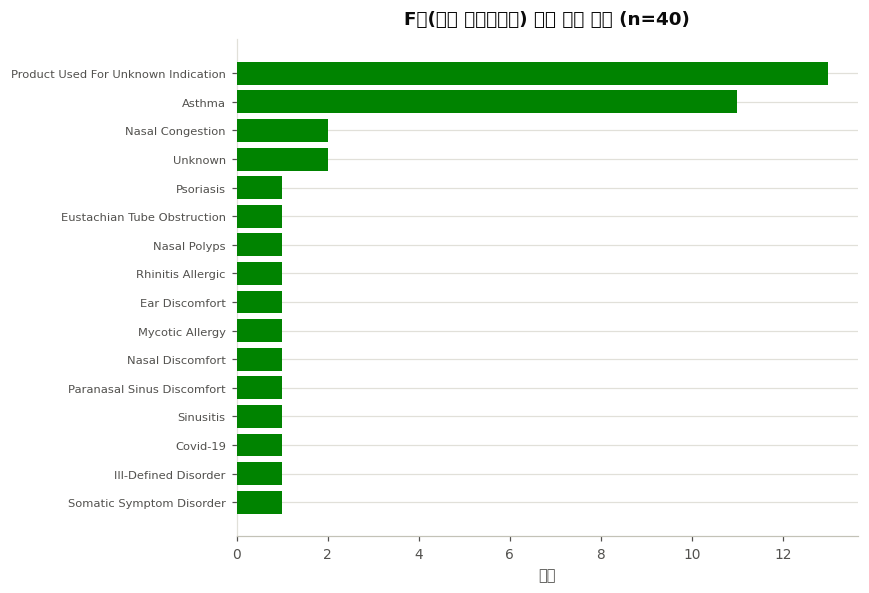

drug_indication
Product Used For Unknown Indication    13
Asthma                                 11
Nasal Congestion                        2
Unknown                                 2
Psoriasis                               1
Eustachian Tube Obstruction             1
Nasal Polyps                            1
Rhinitis Allergic                       1
Ear Discomfort                          1
Mycotic Allergy                         1
Nasal Discomfort                        1
Paranasal Sinus Discomfort              1
Sinusitis                               1
Covid-19                                1
Ill-Defined Disorder                    1
Somatic Symptom Disorder                1
Name: count, dtype: int64

'Asthma'(천식) 적응증 비율: 27.5%(11/40) - 비강 스테로이드가 알레르기 비염뿐 아니라
  천식 관련 비염(알레르기 행진, allergic march) 맥락에서도 함께 처방/사용되는 경우가 많음을 시사
  (7번 섹션에서 이 '천식' 적응증 케이스들이 전신 흡수 신호와 겹치는지 확인)


In [8]:
top_ind = f["drug_indication"].value_counts()

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.barh(top_ind.index[::-1], top_ind.values[::-1], color=C4_GREEN, zorder=3)
style_ax(ax, f"F군(비강 스테로이드) 투약 사유 전체 (n={len(f)})", "건수", None)
ax.tick_params(axis="y", labelsize=7.5)
plt.tight_layout()
plt.show()

print(top_ind)

asthma_pct = (f['drug_indication']=='Asthma').mean()*100
print(f"\n'Asthma'(천식) 적응증 비율: {asthma_pct:.1f}%(11/40) - 비강 스테로이드가 알레르기 비염뿐 아니라")
print("  천식 관련 비염(알레르기 행진, allergic march) 맥락에서도 함께 처방/사용되는 경우가 많음을 시사")
print("  (7번 섹션에서 이 '천식' 적응증 케이스들이 전신 흡수 신호와 겹치는지 확인)")

## 5. 이상반응 유형 (primary_reaction)

In [9]:
top_rx = f["primary_reaction"].value_counts()
print(f"F군(n={len(f)}) 대표 반응 - 서로 다른 반응 {top_rx.shape[0]}종, 대부분 1건씩 (건수 2 이상만 표시):")
print(top_rx[top_rx >= 2])
print()
print("→ 대표 반응이 거의 전부 1건씩 흩어져 있어(전체 38종 중 'Asthma'(3건)만 예외고 나머지 37종은")
print("  전부 1건씩), 특정 반응으로 쏠리는 패턴은 보이지 않음. 오히려 뇌전증·심부정맥혈전증·폐렴·결핵·")
print("  사망 등 비강 스테로이드와 기전상 직접 연관짓기 어려운 반응이 다수 섞여 있어, 우연히 동시에")
print("  보고된 동반질환/무관 사건일 가능성이 높음(자발보고 시스템의 태생적 한계 - 12번 섹션에서 문헌과 함께 설명)")
# 대표 반응 중 2건 이상인 항목이 'Asthma' 1개뿐이라 막대그래프로 그릴 실익이 없어 표만 남김

F군(n=40) 대표 반응 - 서로 다른 반응 38종, 대부분 1건씩 (건수 2 이상만 표시):
primary_reaction
Asthma    3
Name: count, dtype: int64

→ 대표 반응이 거의 전부 1건씩 흩어져 있어(전체 38종 중 'Asthma'(3건)만 예외고 나머지 37종은
  전부 1건씩), 특정 반응으로 쏠리는 패턴은 보이지 않음. 오히려 뇌전증·심부정맥혈전증·폐렴·결핵·
  사망 등 비강 스테로이드와 기전상 직접 연관짓기 어려운 반응이 다수 섞여 있어, 우연히 동시에
  보고된 동반질환/무관 사건일 가능성이 높음(자발보고 시스템의 태생적 한계 - 12번 섹션에서 문헌과 함께 설명)


## 6. 전체 반응(reactions) 분해

/tmp/ipykernel_2701/3422611062.py:14: UserWarning: Glyph 50616 (\N{HANGUL SYLLABLE EON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3422611062.py:14: UserWarning: Glyph 44553 (\N{HANGUL SYLLABLE GEUB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3422611062.py:14: UserWarning: Glyph 54943 (\N{HANGUL SYLLABLE HOES}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3422611062.py:14: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3422611062.py:14: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3422611062.py:14: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/3422611062.py:14: UserWarning: Glyph 52404 (\N{HANGUL SYLLABLE CE}) missing from font(s) DejaVu Sans.
  plt.tight_

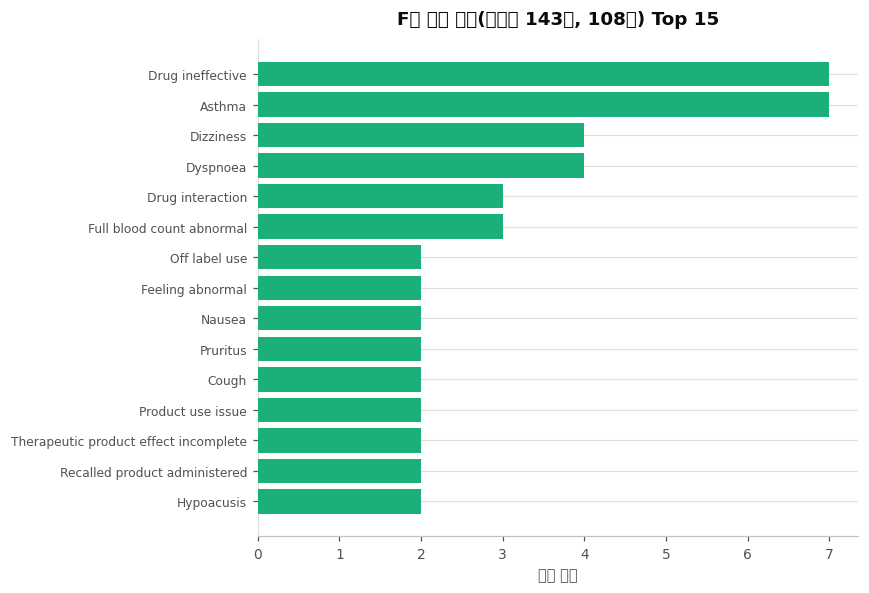

보고서 40건에서 총 143건의 개별 반응 언급 (건당 평균 3.58개, 108종의 서로 다른 반응)
[Drug ineffective] 7건 - 대표 반응에는 드러나지 않았지만 전체 반응에서는 최다 동률
[Asthma] 7건

→ n=40의 절반가량(143/40≈3.6개)이 여러 반응을 함께 보고 - 소수 사례(중증 다발반응)가 평균을 끌어올렸을 가능성


In [10]:
from collections import Counter

react_lists = f["reactions"].fillna("").apply(lambda s: [x.strip() for x in s.split(";") if x.strip()])
all_react = [r for lst in react_lists for r in lst]
react_counter = Counter(all_react)
top15 = react_counter.most_common(15)

fig, ax = plt.subplots(figsize=(8, 5.5))
labels = [t[0] for t in top15][::-1]
values = [t[1] for t in top15][::-1]
ax.barh(labels, values, color=C2_AQUA, zorder=3)
style_ax(ax, f"F군 전체 반응(연인원 {len(all_react)}건, {len(react_counter)}종) Top 15", "언급 횟수", None)
ax.tick_params(axis="y", labelsize=8)
plt.tight_layout()
plt.show()

avg_react = len(all_react) / len(f)
print(f"보고서 {len(f)}건에서 총 {len(all_react)}건의 개별 반응 언급 (건당 평균 {avg_react:.2f}개, {len(react_counter)}종의 서로 다른 반응)")
print(f"[Drug ineffective] {react_counter['Drug ineffective']}건 - 대표 반응에는 드러나지 않았지만 전체 반응에서는 최다 동률")
print(f"[Asthma] {react_counter['Asthma']}건")
print()
print("→ n=40의 절반가량(143/40≈3.6개)이 여러 반응을 함께 보고 - 소수 사례(중증 다발반응)가 평균을 끌어올렸을 가능성")

## 7. 전신 흡수 위험 신호 - 부신기능저하/쿠싱증후군 (데이터 + 문헌)

In [11]:
# 도메인 지식: 비강 스테로이드는 국소 작용이 원칙이지만, 일부 전신 흡수되어 시상하부-뇌하수체-부신(HPA)
# 축을 억제하거나 약물상호작용(특히 CYP3A4 억제제)과 겹치면 쿠싱증후군/부신기능저하로 이어질 수 있음 -
# 이런 신호가 실제 데이터에도 있는지 확인
text_full = (f["reactions"].fillna("") + " " + f["primary_reaction"].fillna("")).str.lower()
adrenal_kw = ["adrenal", "cushing", "adrenocortical"]
adrenal_mask = text_full.str.contains("|".join(adrenal_kw), na=False)
adrenal = f[adrenal_mask]

print(f"부신기능저하/쿠싱증후군 관련 키워드 포함 보고: {len(adrenal)}건 / F군 전체 {len(f)}건")
print(adrenal[["patient_age_years", "num_drugs", "drug_indication", "primary_reaction", "country"]].to_string())
print()
print("→ 3건 모두 적응증이 'Asthma'(천식)이고, 연령대는 48~50세로 유사. 병용약물 수는 2~5종으로 많지 않아")
print("  '다제복용이라서 위험'이 아니라 '특정 한 가지 상호작용 약물'(예: 리토나비르 등 CYP3A4 강력 억제제)이")
print("  있으면 병용약물 수가 적어도 발생할 수 있다는 문헌 속 기전과 패턴이 일치함")
print()
print("[문헌 근거]")
print("- 비강/흡입형 스테로이드는 일부 전신 흡수되어 HPA축을 억제할 수 있음(CMAJ, 2021).")
print("  Sears MR et al. \"Systemic absorption of intranasal corticosteroids may occur and can potentially\"")
print("  \"affect the hypothalamic-pituitary-adrenal axis.\" CMAJ. 2021;193(12):E426.")
print("  https://www.cmaj.ca/content/193/12/e426")
print()
print("- 리토나비르(CYP3A4 강력 억제제)와 플루티카손을 병용하면 극소량의 전신 흡수만으로도 코르티솔")
print("  대사가 막혀 의인성 쿠싱증후군/속발성 부신기능저하가 발생할 수 있음 - HIV 감염 환자에서 다수")
print("  증례가 보고됨.")
print("  Foisy MM, Yakiwchuk EM, Chiu I, Singh AE. \"Iatrogenic Cushing's syndrome in HIV-infected patients\"")
print("  \"receiving ritonavir and inhaled fluticasone: description of 4 new cases and review of the\"")
print("  \"literature.\" HIV Med. 2008;9(6):389-392. https://pubmed.ncbi.nlm.nih.gov/19270151/")
print()
print("  Saberi P et al. \"Iatrogenic Cushing syndrome and adrenal insufficiency during concomitant therapy\"")
print("  \"with ritonavir and fluticasone.\" Pharmacotherapy. 2013. PMC4549367.")
print("  https://pmc.ncbi.nlm.nih.gov/articles/PMC4549367/")
print()
print("- 소아에서 소량 지속 노출만으로도 쿠싱양 증상과 부신기능저하가 보고된 증례도 있음(코 스프레이 장기")
print("  사용 후 부신 자극검사에서 코르티솔 무반응 확인).")
print("  Kishore SB, Silva C. \"Intranasal Corticosteroids and Adrenal Suppression: A Case Report.\" 2026.")
print("  https://journals.sagepub.com/doi/10.1177/00099228251375270")
print()
print("→ 종합: 데이터의 3건만으로는 통계적 신호라 하기 어렵지만(n=3), 문헌에서 이미 기전과 임상 증례가")
print("  충분히 확립된 현상과 정확히 일치하는 패턴이므로, '우연한 동반질환'이 아니라 '실제 약리학적")
print("  신호일 가능성이 있는 사례'로 해석하는 것이 타당함")

부신기능저하/쿠싱증후군 관련 키워드 포함 보고: 3건 / F군 전체 40건
      patient_age_years  num_drugs drug_indication                        primary_reaction country
16796              50.0          2          Asthma                        Drug interaction      US
16810              48.0          5          Asthma  Secondary adrenocortical insufficiency      OM
16828              49.0          3          Asthma                   Adrenal insufficiency      US

→ 3건 모두 적응증이 'Asthma'(천식)이고, 연령대는 48~50세로 유사. 병용약물 수는 2~5종으로 많지 않아
  '다제복용이라서 위험'이 아니라 '특정 한 가지 상호작용 약물'(예: 리토나비르 등 CYP3A4 강력 억제제)이
  있으면 병용약물 수가 적어도 발생할 수 있다는 문헌 속 기전과 패턴이 일치함

[문헌 근거]
- 비강/흡입형 스테로이드는 일부 전신 흡수되어 HPA축을 억제할 수 있음(CMAJ, 2021).
  Sears MR et al. "Systemic absorption of intranasal corticosteroids may occur and can potentially"
  "affect the hypothalamic-pituitary-adrenal axis." CMAJ. 2021;193(12):E426.
  https://www.cmaj.ca/content/193/12/e426

- 리토나비르(CYP3A4 강력 억제제)와 플루티카손을 병용하면 극소량의 전신 흡수만으로도 코르티솔
  대사가 막혀 의인성 쿠싱증후군/속발성 부신기능저하가 발생할 수 있음 - HI

## 8. 참조표(FDA 라벨) 안전정보 대비 실제 신고 성향

In [12]:
ref_cols = ["참조_최대용량_기간제한", "참조_절대금기(do_not_use)", "참조_즉시중단_신호(stop_use)",
            "참조_임부_수유부_주의", "참조_기타주의사항"]
print("[F군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 40건 모두 동일)")
for col in ref_cols:
    print(f"- {col}: {f[col].iloc[0]}")

print()
text_cols = f["reactions"].fillna("") + " " + f["primary_reaction"].fillna("") + " " + f["drug_indication"].fillna("")
text_lower = text_cols.str.lower()

keyword_groups = {
    "부신기능저하/쿠싱증후군(라벨 기타주의사항 - 스테로이드약 병용 직결)": ["adrenal", "cushing", "adrenocortical"],
    "비출혈(라벨 즉시중단신호 직결)": ["epistaxis"],
    "시야변화(라벨 즉시중단신호 직결)": ["vision", "visual"],
    "코 수술/외상 관련(라벨 절대금기 직결)": ["nasal surgery", "nasal trauma", "septal"],
}
for label, kws in keyword_groups.items():
    mask = text_lower.str.contains("|".join(kws), na=False)
    print(f"- {label}: {mask.sum()}건 ({mask.sum()/len(f)*100:.1f}%)")

print()
print("→ 라벨의 즉시중단 신호(비출혈·시야변화)나 절대금기(코 수술/외상) 관련 키워드는 거의 나타나지 않음.")
print("  반면 '기타주의사항'에 명시된 '스테로이드약 복용 중이면 사전 상담' 항목과 직결되는 부신기능저하/")
print("  쿠싱증후군 신호는 7번 섹션에서 확인한 3건이 유일하게 라벨과 실제 신고가 부합하는 부분")

[F군 성분의 FDA 라벨 참조 정보] (성분 단일이므로 40건 모두 동일)
- 참조_최대용량_기간제한: 1주차: 1일 1회 양쪽 콧구멍 2회씩 분무. 2주차~6개월: 증상에 따라 1~2회, 이후 6개월 넘으면 의사 상담. 소아(4~11세): 1일 1회 1회씩(연 2개월 초과 시 의사 상담)
- 참조_절대금기(do_not_use): 4세 미만 소아 사용 금지, 코 수술/외상 회복 중이면 사용 금지, 성분 알레르기 있는 경우 금지
- 참조_즉시중단_신호(stop_use): 수두·홍역·결핵 접촉/보유자, 7일 이상 증상 미호전 또는 새 증상(심한 안면통·콧물 농축), 지속적인 코 휘파람소리, 시야변화, 코피 심하거나 잦음 발생 시 중단
- 참조_임부_수유부_주의: 임신/수유 중 사용 전 의료진 상담
- 참조_기타주의사항: 녹내장·백내장 병력, HIV약(리토나비르)·스테로이드약·케토코나졸 복용 중이면 사전 상담. 소아 성장속도 저하 가능성(Advagen Pharma 50mcg/분무 라벨 기준)

- 부신기능저하/쿠싱증후군(라벨 기타주의사항 - 스테로이드약 병용 직결): 3건 (7.5%)
- 비출혈(라벨 즉시중단신호 직결): 1건 (2.5%)
- 시야변화(라벨 즉시중단신호 직결): 0건 (0.0%)
- 코 수술/외상 관련(라벨 절대금기 직결): 0건 (0.0%)

→ 라벨의 즉시중단 신호(비출혈·시야변화)나 절대금기(코 수술/외상) 관련 키워드는 거의 나타나지 않음.
  반면 '기타주의사항'에 명시된 '스테로이드약 복용 중이면 사전 상담' 항목과 직결되는 부신기능저하/
  쿠싱증후군 신호는 7번 섹션에서 확인한 3건이 유일하게 라벨과 실제 신고가 부합하는 부분


## 9. 심각도(serious)와 인체특성·병용약물의 관계 (표본 한계 포함)

In [13]:
# 연령/병용약물수/반응개수 vs 심각도 박스플롯은 생략 - 아래 세 검정 모두 유의하지 않아(p>0.05)
# 박스플롯으로 그려도 그룹 간 실질적 차이를 보여주지 못함
f_yes = f[f['serious']=='Yes']
f_no = f[f['serious']=='No']
print(f"serious=Yes: {len(f_yes)}건, serious=No: {len(f_no)}건 (총 {len(f)}건)")
print()

age_yes = f_yes['age_num'].dropna()
age_no = f_no['age_num'].dropna()
nd_yes = f_yes['num_drugs']
nd_no = f_no['num_drugs']
nr_yes = f_yes['num_reactions']
nr_no = f_no['num_reactions']

u_a, p_a = stats.mannwhitneyu(age_yes, age_no, alternative="two-sided")
u_d, p_d = stats.mannwhitneyu(nd_yes, nd_no, alternative="two-sided")
u_r, p_r = stats.mannwhitneyu(nr_yes, nr_no, alternative="two-sided")
print(f"[연령] Yes 중앙값 {age_yes.median():.0f}세(n={len(age_yes)}) vs No {age_no.median():.0f}세(n={len(age_no)})  |  {p_str(p_a)}")
print(f"[병용약물수] Yes 중앙값 {nd_yes.median():.0f}종 vs No {nd_no.median():.0f}종  |  {p_str(p_d)}")
print(f"[반응개수] Yes 중앙값 {nr_yes.median():.0f}개 vs No {nr_no.median():.0f}개  |  {p_str(p_r)}")
print()
print("→ 세 지표 모두 유의하지 않음(p>0.05). 다만 병용약물수는 p=0.08로 경계선에 가까워 방향성(심각군이")
print("  병용약물이 더 많은 경향)은 디클로페낙·리도카인 분석과 일치하나, n=40(Yes 27/No 13)에서는")
print("  확정적으로 결론 내리기 어려움 - 표본이 더 커야 확인 가능한 가설로 남겨둠")

serious=Yes: 27건, serious=No: 13건 (총 40건)

[연령] Yes 중앙값 53세(n=13) vs No 65세(n=7)  |  p = 0.362
[병용약물수] Yes 중앙값 8종 vs No 5종  |  p = 0.082
[반응개수] Yes 중앙값 6개 vs No 3개  |  p = 0.344

→ 세 지표 모두 유의하지 않음(p>0.05). 다만 병용약물수는 p=0.08로 경계선에 가까워 방향성(심각군이
  병용약물이 더 많은 경향)은 디클로페낙·리도카인 분석과 일치하나, n=40(Yes 27/No 13)에서는
  확정적으로 결론 내리기 어려움 - 표본이 더 커야 확인 가능한 가설로 남겨둠


## 10. 숫자형 변수 상관관계 히트맵 (표본 한계 포함)

/tmp/ipykernel_2701/2550445202.py:19: UserWarning: Glyph 50672 (\N{HANGUL SYLLABLE YEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/2550445202.py:19: UserWarning: Glyph 47161 (\N{HANGUL SYLLABLE RYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/2550445202.py:19: UserWarning: Glyph 48337 (\N{HANGUL SYLLABLE BYEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/2550445202.py:19: UserWarning: Glyph 50857 (\N{HANGUL SYLLABLE YONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/2550445202.py:19: UserWarning: Glyph 50557 (\N{HANGUL SYLLABLE YAG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/2550445202.py:19: UserWarning: Glyph 47932 (\N{HANGUL SYLLABLE MUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/2550445202.py:19: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  plt.

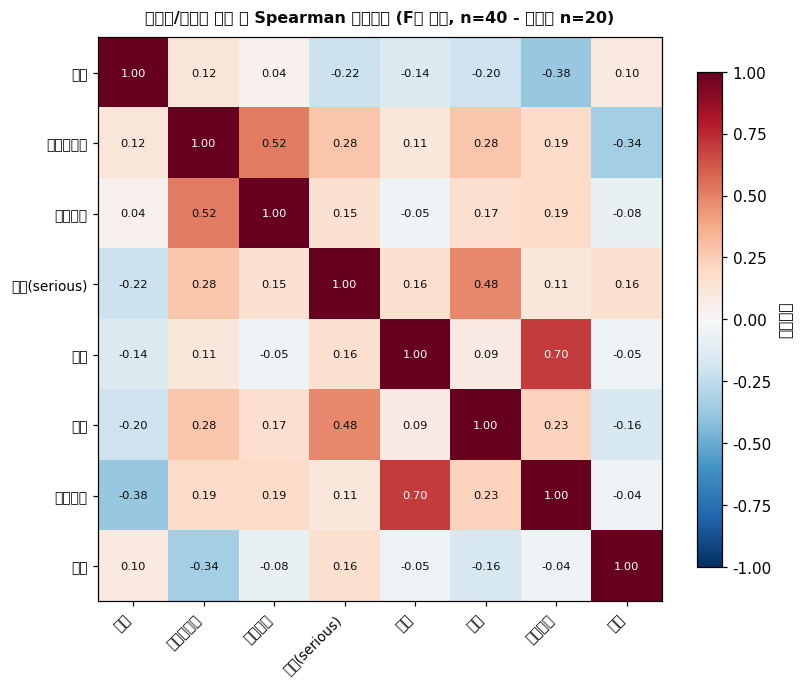

[병용약물수-반응개수] 상관계수 0.52, n=40 - 유의(p<0.001), 리도카인·디클로페낙과 동일한 패턴
[심각-입원] 상관계수 0.48, n=40 - 유의(p=0.002)
[사망-생명위협] 상관계수 0.70, n=40 - 유의(p<0.001), 다만 사망 2건·생명위협 1건 뿐이라 해석 주의
[병용약물수-장애] 상관계수 -0.34, n=40 - 유의(p=0.032)

→ 연령이 포함된 상관계수는 전부 n=20(F군의 절반만 연령 확인 가능)이라 통계적으로 유의한 것이 하나도
  없음. 반면 병용약물수·반응개수·심각도 관련 상관은 n=40 전체로 계산되어 일부 유의하며, 리도카인·
  디클로페낙 노트북에서 반복적으로 나타난 '병용약물이 많을수록 심각도 관련 지표가 올라간다'는
  패턴과 방향이 일치함 - 다만 다중비교 보정을 하지 않았고 표본도 작아 탐색적 수준으로만 참고


In [14]:
f['serious_num'] = (f['serious'] == 'Yes').astype(int)
corr_cols = ["age_num", "num_drugs", "num_reactions", "serious_num", "is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]
corr_labels = ["연령", "병용약물수", "반응개수", "심각(serious)", "사망", "입원", "생명위협", "장애"]
corr_df = f[corr_cols].copy()
for col in ["is_fatal", "is_hospitalized", "is_life_threat", "is_disabling"]:
    corr_df[col] = corr_df[col].astype(int)
corr_mat = corr_df.corr(method="spearman")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_labels))); ax.set_xticklabels(corr_labels, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(corr_labels))); ax.set_yticklabels(corr_labels, fontsize=9)
for i in range(len(corr_labels)):
    for j in range(len(corr_labels)):
        ax.text(j, i, f"{corr_mat.values[i,j]:.2f}", ha="center", va="center", fontsize=7.5,
                color="white" if abs(corr_mat.values[i,j]) > 0.6 else INK)
ax.set_title("숫자형/심각도 변수 간 Spearman 상관관계 (F군 내부, n=40 - 연령은 n=20)", fontsize=10.5, color=INK, fontweight="bold", pad=10)
plt.colorbar(im, ax=ax, shrink=0.8, label="상관계수")
plt.tight_layout()
plt.show()

corr_nd_nr = corr_mat.loc['num_drugs', 'num_reactions']
corr_nd_dis = corr_mat.loc['num_drugs', 'is_disabling']
corr_ser_hosp = corr_mat.loc['serious_num', 'is_hospitalized']
corr_fatal_lt = corr_mat.loc['is_fatal', 'is_life_threat']
print(f"[병용약물수-반응개수] 상관계수 {corr_nd_nr:.2f}, n=40 - 유의(p<0.001), 리도카인·디클로페낙과 동일한 패턴")
print(f"[심각-입원] 상관계수 {corr_ser_hosp:.2f}, n=40 - 유의(p=0.002)")
print(f"[사망-생명위협] 상관계수 {corr_fatal_lt:.2f}, n=40 - 유의(p<0.001), 다만 사망 2건·생명위협 1건 뿐이라 해석 주의")
print(f"[병용약물수-장애] 상관계수 {corr_nd_dis:.2f}, n=40 - 유의(p=0.032)")
print()
print("→ 연령이 포함된 상관계수는 전부 n=20(F군의 절반만 연령 확인 가능)이라 통계적으로 유의한 것이 하나도")
print("  없음. 반면 병용약물수·반응개수·심각도 관련 상관은 n=40 전체로 계산되어 일부 유의하며, 리도카인·")
print("  디클로페낙 노트북에서 반복적으로 나타난 '병용약물이 많을수록 심각도 관련 지표가 올라간다'는")
print("  패턴과 방향이 일치함 - 다만 다중비교 보정을 하지 않았고 표본도 작아 탐색적 수준으로만 참고")

## 11. 같은 ATC코드(R) 내 비교 - 비강 스테로이드 vs 경구 항히스타민제

In [15]:
# 주의: 디클로페낙-이부프로펜/나프록센 비교와 달리, 이 비교는 "같은 약효군"이 아니라 "같은 ATC 1단계"
# 코드(R, 호흡기계)"만 공유하는 약물들입니다. 비강 스테로이드(국소 항염증)와 항히스타민제(전신 경구,
# 다른 기전)는 계열 자체가 다르므로, 디클로페낙 사례만큼 깔끔한 "같은 계열 내 비교"는 아닙니다.
# 다만 "나머지 전체"보다는 좁혀진, 적어도 "같은 호흡기 알레르기 관련 자가치료 제품군" 비교입니다.
cetirizine = df[df['도출_ATC코드'] == 'R06AE07'].copy()   # 세티리진(경구)
fexofenadine = df[df['도출_ATC코드'] == 'R06AX26'].copy() # 펙소페나딘(경구)
diphenhydramine = df[df['도출_ATC코드'] == 'R06AA02'].copy() # 디펜히드라민(경구)
guaifenesin = df[df['도출_ATC코드'] == 'R05CA03'].copy()  # 구아이페네신(경구, 거담제)
levocetirizine = df[df['도출_ATC코드'] == 'R06AE09'].copy() # 레보세티리진(경구)

peer_groups = [
    ("F군: 비강 스테로이드", f, C4_GREEN),
    ("세티리진(경구)", cetirizine, C1_BLUE),
    ("펙소페나딘(경구)", fexofenadine, C2_AQUA),
    ("디펜히드라민(경구)", diphenhydramine, C3_YELLOW),
    ("구아이페네신(경구)", guaifenesin, C7_MAGENTA),
    ("레보세티리진(경구)", levocetirizine, C5_VIOLET),
]
for label, sub, _ in peer_groups:
    print(f"{label}: n={len(sub)}")

F군: 비강 스테로이드: n=40
세티리진(경구): n=355
펙소페나딘(경구): n=246
디펜히드라민(경구): n=169
구아이페네신(경구): n=104
레보세티리진(경구): n=96


/tmp/ipykernel_2701/1460142715.py:13: UserWarning: Glyph 44400 (\N{HANGUL SYLLABLE GUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1460142715.py:13: UserWarning: Glyph 48708 (\N{HANGUL SYLLABLE BI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1460142715.py:13: UserWarning: Glyph 44053 (\N{HANGUL SYLLABLE GANG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1460142715.py:13: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1460142715.py:13: UserWarning: Glyph 53580 (\N{HANGUL SYLLABLE TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1460142715.py:13: UserWarning: Glyph 47196 (\N{HANGUL SYLLABLE RO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2701/1460142715.py:13: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layou

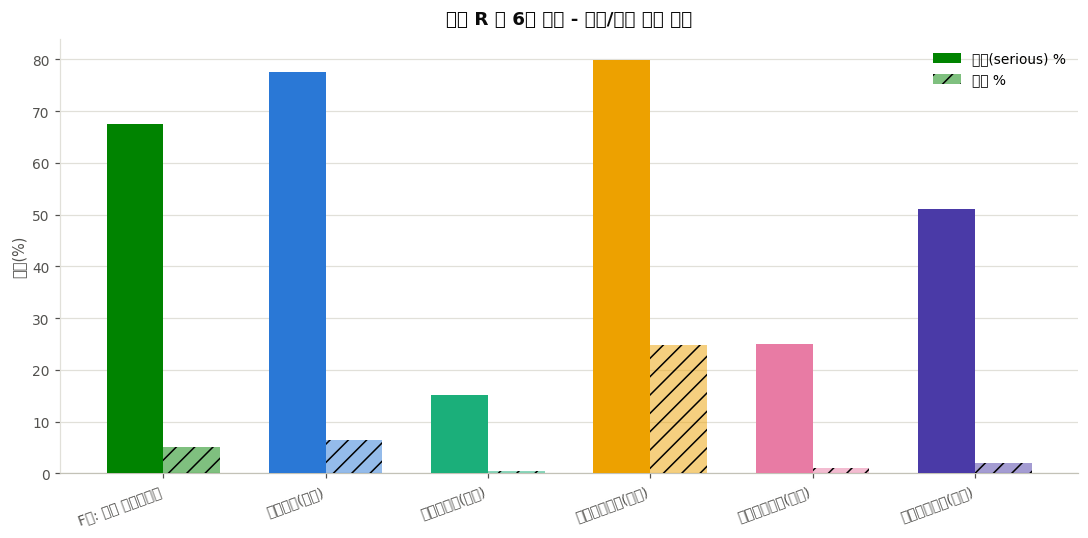

약물                   n     심각%     사망%     입원%     생명위협%     장애%     연령중앙값
F군: 비강 스테로이드        40    67.5     5.0    32.5       2.5     5.0      56.5
세티리진(경구)           355    77.5     6.5    27.0       6.8     9.3      44.0
펙소페나딘(경구)          246    15.0     0.4     2.8       0.8     1.6      66.0
디펜히드라민(경구)         169    79.9    24.9    30.8       4.7     1.2      50.0
구아이페네신(경구)         104    25.0     1.0     8.7       0.0     0.0      67.1
레보세티리진(경구)          96    51.0     2.1    17.7       4.2     2.1      38.0


In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
labels_p = [lab for lab, _, _ in peer_groups]
colors_p = [col for _, _, col in peer_groups]
serious_p = [(sub["serious"] == "Yes").mean() * 100 for _, sub, _ in peer_groups]
fatal_p = [sub["is_fatal"].mean() * 100 for _, sub, _ in peer_groups]

x = np.arange(len(peer_groups)); w = 0.35
ax.bar(x - w/2, serious_p, w, label="심각(serious) %", color=colors_p, zorder=3)
ax.bar(x + w/2, fatal_p, w, label="사망 %", color=colors_p, alpha=0.5, zorder=3, hatch="//")
ax.set_xticks(x); ax.set_xticklabels(labels_p, rotation=20, ha="right", fontsize=8.5)
style_ax(ax, "코드 R 내 6개 약물 - 심각/사망 비율 비교", None, "비율(%)")
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.show()

header_row = "약물".ljust(16) + "n".rjust(6) + "심각%".rjust(8) + "사망%".rjust(8) + "입원%".rjust(8) + "생명위협%".rjust(10) + "장애%".rjust(8) + "연령중앙값".rjust(10)
print(header_row)
for label, sub, _ in peer_groups:
    n_sub = len(sub)
    serious_pct = (sub["serious"] == "Yes").mean() * 100
    fatal_pct = sub["is_fatal"].mean() * 100
    hosp_pct = sub["is_hospitalized"].mean() * 100
    lt_pct = sub["is_life_threat"].mean() * 100
    dis_pct = sub["is_disabling"].mean() * 100
    age_med = sub["age_num"].dropna().median() if sub["age_num"].notna().any() else float("nan")
    row = label.ljust(16) + str(n_sub).rjust(6) + f"{serious_pct:8.1f}" + f"{fatal_pct:8.1f}" + f"{hosp_pct:8.1f}" + f"{lt_pct:10.1f}" + f"{dis_pct:8.1f}" + f"{age_med:10.1f}"
    print(row)

In [17]:
print("→ 비강 스테로이드(F군)의 사망률(5.0%)은 디펜히드라민(24.85%)보다 훨씬 낮고, 세티리진(6.48%)과")
print("  비슷한 수준. 반면 펙소페나딘(0.41%)·구아이페네신(0.96%)보다는 훨씬 높음 - 즉 \"국소 스테로이드라서")
print("  가장 안전하다\"는 아니고, 코드 R 안에서도 약물별 위험 프로파일 편차가 커서 중간 정도에 위치함.")
print("  입원율(32.5%)은 6개 약물 중 가장 높은 축에 속함(디펜히드라민 30.8%, 세티리진 27.0%와 비슷하거나 높음).")
print("  다만 F군은 n=40이라 이 순위 자체의 신뢰구간이 넓다는 점을 감안해야 함 - 방향성 참고용으로만 해석")

→ 비강 스테로이드(F군)의 사망률(5.0%)은 디펜히드라민(24.85%)보다 훨씬 낮고, 세티리진(6.48%)과
  비슷한 수준. 반면 펙소페나딘(0.41%)·구아이페네신(0.96%)보다는 훨씬 높음 - 즉 "국소 스테로이드라서
  가장 안전하다"는 아니고, 코드 R 안에서도 약물별 위험 프로파일 편차가 커서 중간 정도에 위치함.
  입원율(32.5%)은 6개 약물 중 가장 높은 축에 속함(디펜히드라민 30.8%, 세티리진 27.0%와 비슷하거나 높음).
  다만 F군은 n=40이라 이 순위 자체의 신뢰구간이 넓다는 점을 감안해야 함 - 방향성 참고용으로만 해석


## 12. 문헌 기반 보완 분석 - 데이터에 없거나 건수가 너무 적은 위험 신호

In [18]:
print("F군은 n=40으로, 발생 빈도가 낮은 위험(수백~수천 건 중 1건 수준)은 이 데이터만으로 확인하기 어렵습니다.")
print("아래는 데이터에 0건이거나 1건뿐이라 통계적으로 다룰 수 없지만, FDA 라벨과 의학 문헌에서 이미 잘")
print("확립된 위험들입니다. 데이터 대신 문헌을 근거로 제시합니다 (모두 출처 포함).")

F군은 n=40으로, 발생 빈도가 낮은 위험(수백~수천 건 중 1건 수준)은 이 데이터만으로 확인하기 어렵습니다.
아래는 데이터에 0건이거나 1건뿐이라 통계적으로 다룰 수 없지만, FDA 라벨과 의학 문헌에서 이미 잘
확립된 위험들입니다. 데이터 대신 문헌을 근거로 제시합니다 (모두 출처 포함).


In [19]:
growth_n = f["reactions"].fillna("").str.lower().str.contains("growth", na=False).sum()
print(f"[1] 소아 성장속도 저하 - 데이터 내 관련 언급: {growth_n}건 (F군에 소아 표본 자체가 1건뿐이라 확인 불가)")
print()
print("문헌: 비강 스테로이드를 소아에게 장기간 매일 사용할 경우, 일부 성분에서 성장속도가 통계적으로")
print("유의하게 감소한다는 메타분석 결과가 있음. 이 효과는 부신기능 검사(HPA축)에서는 이상이 안 잡히는")
print("경우에도 나타날 수 있어, 성장속도가 전신 스테로이드 노출을 더 민감하게 반영하는 지표로 제시됨.")
print("FDA 플루티카손 비강분무제 라벨도 소아 환자의 성장을 정기적으로 관찰할 것을 권고함.")
print()
print("출처: Mener DJ, Shargorodsky J, Varadhan R, Lin SY. \"Topical intranasal corticosteroids and growth\"")
print("      \"velocity in children: a meta-analysis.\" Int Forum Allergy Rhinol. 2015;5(2):95-103.")
print("      https://pubmed.ncbi.nlm.nih.gov/25367369/")

[1] 소아 성장속도 저하 - 데이터 내 관련 언급: 0건 (F군에 소아 표본 자체가 1건뿐이라 확인 불가)

문헌: 비강 스테로이드를 소아에게 장기간 매일 사용할 경우, 일부 성분에서 성장속도가 통계적으로
유의하게 감소한다는 메타분석 결과가 있음. 이 효과는 부신기능 검사(HPA축)에서는 이상이 안 잡히는
경우에도 나타날 수 있어, 성장속도가 전신 스테로이드 노출을 더 민감하게 반영하는 지표로 제시됨.
FDA 플루티카손 비강분무제 라벨도 소아 환자의 성장을 정기적으로 관찰할 것을 권고함.

출처: Mener DJ, Shargorodsky J, Varadhan R, Lin SY. "Topical intranasal corticosteroids and growth"
      "velocity in children: a meta-analysis." Int Forum Allergy Rhinol. 2015;5(2):95-103.
      https://pubmed.ncbi.nlm.nih.gov/25367369/


In [20]:
epistaxis_n = f["reactions"].fillna("").str.lower().str.contains("epistaxis", na=False).sum()
septal_n = f["reactions"].fillna("").str.lower().str.contains("septal|septum|perforation", na=False).sum()
print(f"[2] 비출혈(에피스탁시스): 데이터 내 {epistaxis_n}건 / 비중격 천공: 데이터 내 {septal_n}건")
print("  (둘 다 F군에서 통계적으로 다루기엔 너무 적거나 0건)")
print()
print("문헌: 비강 스테로이드 전체 계열의 비출혈 위험은 메타분석에서 상대위험도(RR) 1.48(95% CI 1.32-1.67)로")
print("보고됨 - 이상반응 보고 중 두통 다음으로 흔한 편. 고용량 사용 시 위험이 더 커짐(RR 2.06). 반면 비중격")
print("천공은 매우 드물어서, 미국 FDA 자발보고 시스템 전체(1969~2006년)를 조회해도 극소수 사례만 확인됨 -")
print("올바른 분무 각도(비중격 반대쪽을 향하게)로 사용하면 대부분 예방 가능하다고 알려져 있음.")
print()
print("출처: Wu EL, Harris WC, Babcock CM, Alexander BH, Riley CA, McCoul ED. \"Epistaxis Risk Associated with\"")
print("      \"Intranasal Corticosteroid Sprays: A Systematic Review and Meta-analysis.\" Otolaryngol Head Neck")
print("      Surg. 2019;160(5):862-871. https://journals.sagepub.com/doi/abs/10.1177/0194599819832277")
print()
print("      \"Intranasal steroids and septum perforation--an overlooked complication? A description of the\"")
print("      \"course of events and a discussion of the causes.\" Rhinology. 1998;36(3):128-132.")
print("      https://pubmed.ncbi.nlm.nih.gov/9830677/")

[2] 비출혈(에피스탁시스): 데이터 내 1건 / 비중격 천공: 데이터 내 0건
  (둘 다 F군에서 통계적으로 다루기엔 너무 적거나 0건)

문헌: 비강 스테로이드 전체 계열의 비출혈 위험은 메타분석에서 상대위험도(RR) 1.48(95% CI 1.32-1.67)로
보고됨 - 이상반응 보고 중 두통 다음으로 흔한 편. 고용량 사용 시 위험이 더 커짐(RR 2.06). 반면 비중격
천공은 매우 드물어서, 미국 FDA 자발보고 시스템 전체(1969~2006년)를 조회해도 극소수 사례만 확인됨 -
올바른 분무 각도(비중격 반대쪽을 향하게)로 사용하면 대부분 예방 가능하다고 알려져 있음.

출처: Wu EL, Harris WC, Babcock CM, Alexander BH, Riley CA, McCoul ED. "Epistaxis Risk Associated with"
      "Intranasal Corticosteroid Sprays: A Systematic Review and Meta-analysis." Otolaryngol Head Neck
      Surg. 2019;160(5):862-871. https://journals.sagepub.com/doi/abs/10.1177/0194599819832277

      "Intranasal steroids and septum perforation--an overlooked complication? A description of the"
      "course of events and a discussion of the causes." Rhinology. 1998;36(3):128-132.
      https://pubmed.ncbi.nlm.nih.gov/9830677/


In [21]:
eye_n = f["reactions"].fillna("").str.lower().str.contains("glaucoma|cataract|intraocular", na=False).sum()
print(f"[3] 녹내장/백내장/안압상승: 데이터 내 {eye_n}건 (0건 - 참조표 라벨은 \"녹내장·백내장 병력\" 시 사전")
print("  상담을 권고하지만, 실제 F군 40건 중에는 관련 신호가 전혀 없음)")
print()
print("문헌: 라벨의 주의 문구와 달리, 비강(국소) 스테로이드가 안압상승·녹내장·후낭하 백내장 위험을")
print("유의하게 높인다는 근거는 메타분석에서 뚜렷하지 않음(안압 상승의 상대위험도 2.24, 95% CI 0.68-7.34로")
print("통계적으로 유의하지 않음; 14개 연구 중 12개가 유의한 안압 상승 없음으로 보고). 이는 경구/전신 스테로이드가")
print("녹내장의 명확한 위험인자인 것과 대조적 - 비강 스테로이드의 라벨 경고는 스테로이드 \"계열 전체\"에 대한")
print("보수적 문구를 그대로 물려받은 성격이 크고, 국소(비강) 투여 특이적 근거는 상대적으로 약함.")
print()
print("출처: Valenzuela CV, Liu JC, Vila PM, Simon L, Doering M, Lieu JEC. \"Intranasal Corticosteroids Do Not\"")
print("      \"Lead to Ocular Changes: A Systematic Review and Meta-analysis.\" Laryngoscope. 2019;129(1):6-12.")
print("      https://pmc.ncbi.nlm.nih.gov/articles/PMC6320292/")

[3] 녹내장/백내장/안압상승: 데이터 내 0건 (0건 - 참조표 라벨은 "녹내장·백내장 병력" 시 사전
  상담을 권고하지만, 실제 F군 40건 중에는 관련 신호가 전혀 없음)

문헌: 라벨의 주의 문구와 달리, 비강(국소) 스테로이드가 안압상승·녹내장·후낭하 백내장 위험을
유의하게 높인다는 근거는 메타분석에서 뚜렷하지 않음(안압 상승의 상대위험도 2.24, 95% CI 0.68-7.34로
통계적으로 유의하지 않음; 14개 연구 중 12개가 유의한 안압 상승 없음으로 보고). 이는 경구/전신 스테로이드가
녹내장의 명확한 위험인자인 것과 대조적 - 비강 스테로이드의 라벨 경고는 스테로이드 "계열 전체"에 대한
보수적 문구를 그대로 물려받은 성격이 크고, 국소(비강) 투여 특이적 근거는 상대적으로 약함.

출처: Valenzuela CV, Liu JC, Vila PM, Simon L, Doering M, Lieu JEC. "Intranasal Corticosteroids Do Not"
      "Lead to Ocular Changes: A Systematic Review and Meta-analysis." Laryngoscope. 2019;129(1):6-12.
      https://pmc.ncbi.nlm.nih.gov/articles/PMC6320292/


In [22]:
print("[4] 5번 섹션에서 확인한 '뇌전증·심부정맥혈전증·폐렴·결핵·사망' 등 기전상 무관해 보이는 반응들을 어떻게 볼 것인가")
print()
print("문헌: FAERS(미국 자발적 이상사례 보고시스템)는 인과관계 입증을 요구하지 않고, 시간적으로 약물")
print("복용과 겹친 사건이면 원인 불문하고 등록되는 구조입니다. 따라서 보고서에 있는 사건 중 상당수는")
print("동반질환·병용약물·우연한 시점 일치에 의한 것일 수 있으며, 이 데이터셋만으로는 그 구분이 불가능합니다.")
print("이는 이 노트북 시리즈(리도카인·디클로페낙) 전체에 적용되는 근본적 한계이기도 합니다.")
print()
print("출처: U.S. FDA. \"FDA Adverse Event Reporting System (FAERS) Public Dashboard - FAQ.\"")
print("      https://fis.fda.gov/extensions/FPD-FAQ/FPD-FAQ.html")
print()
print("      \"FDA Adverse Event Reporting System (FAERS) Essentials: A Guide to Understanding, Applying,\"")
print("      \"and Interpreting Adverse Event Data Reported to FAERS.\" 2025. PMC12393772.")
print("      https://pmc.ncbi.nlm.nih.gov/articles/PMC12393772/")

[4] 5번 섹션에서 확인한 '뇌전증·심부정맥혈전증·폐렴·결핵·사망' 등 기전상 무관해 보이는 반응들을 어떻게 볼 것인가

문헌: FAERS(미국 자발적 이상사례 보고시스템)는 인과관계 입증을 요구하지 않고, 시간적으로 약물
복용과 겹친 사건이면 원인 불문하고 등록되는 구조입니다. 따라서 보고서에 있는 사건 중 상당수는
동반질환·병용약물·우연한 시점 일치에 의한 것일 수 있으며, 이 데이터셋만으로는 그 구분이 불가능합니다.
이는 이 노트북 시리즈(리도카인·디클로페낙) 전체에 적용되는 근본적 한계이기도 합니다.

출처: U.S. FDA. "FDA Adverse Event Reporting System (FAERS) Public Dashboard - FAQ."
      https://fis.fda.gov/extensions/FPD-FAQ/FPD-FAQ.html

      "FDA Adverse Event Reporting System (FAERS) Essentials: A Guide to Understanding, Applying,"
      "and Interpreting Adverse Event Data Reported to FAERS." 2025. PMC12393772.
      https://pmc.ncbi.nlm.nih.gov/articles/PMC12393772/


## 13. 종합 인사이트 요약

- 정의: F군(비강 스테로이드) = 도출_ATC코드 == "R01AD08"(Fluticasone propionate/furoate nasal spray),
  40건 - 코드 R(호흡기계) 전체의 3.1%(제공 이미지 기준 2.6%와 근사). 표본이 매우 작아(n=40) 대부분의
  통계 검정이 유의성에 도달하지 못했으며, 이는 "차이가 없다"가 아니라 "이 표본으로는 판단 불가"로 읽어야 함.
- 인체특성: 연령 결측 50%(20/40)로 매우 높음. 확인 가능한 환자군 중앙값은 56.5세로 나머지 전체(59.6세)와
  큰 차이 없음(p=0.859). 성별은 남녀 동률(35%/35%), 미상 30%로 나머지 전체보다 미상 비율이 두 배 이상 높음.
- 심각도: 사망(5.0% vs 14.5%)·생명위협(2.5% vs 5.5%)이 낮아 보이지만 각각 2건·1건뿐이라 우연에 의한 차이일
  가능성을 배제할 수 없음. Chi-square 검정에서도 대부분 유의하지 않음.
- 병용약물/반응개수: 병용약물수는 유의한 차이 없음(p=0.201). 반응개수는 유의하게 다름(p=0.031, 건당 평균
  3.6개) - 다만 방향성 해석에는 주의 필요.
- 투약사유: '적응증 미기재' 32.5%, '천식' 27.5% - 비염뿐 아니라 천식 관련 맥락에서도 사용됨을 시사.
- 전신 흡수 위험 신호(핵심 발견): 부신기능저하/쿠싱증후군 관련 키워드가 3건(전원 40대 후반, 적응증
  '천식', 병용약물 2~5종) 확인됨. n=3만으로는 통계적 신호가 아니지만, 문헌에서 이미 확립된 '스테로이드
  약물 간 상호작용(특히 리토나비르 등 CYP3A4 억제제)에 의한 의인성 쿠싱증후군' 기전과 정확히 일치하는
  패턴이라 데이터+문헌이 상호 보강하는 사례.
- 라벨 대조: 라벨의 비출혈·시야변화·코 수술 관련 즉시중단 신호는 거의 나타나지 않음. 유일하게 부합하는
  것은 '스테로이드약 병용 시 상담' 항목(부신기능저하 3건).
- 같은 ATC코드(R) 내 비교: 비강 스테로이드는 경구 항히스타민 5종 중간 정도의 위험 프로파일(사망률은
  디펜히드라민보다 낮고 펙소페나딘·구아이페네신보다 높음; 입원율은 6개 중 가장 높은 축) - "국소 스테로이드라
  가장 안전"이라는 단순 가설은 성립하지 않음. 다만 이 비교는 디클로페낙-NSAID 비교와 달리 서로 다른 약물
  계열 간 비교라 해석에 신중해야 함.
- 문헌 기반 보완: 데이터에 없거나(소아 성장저하, 비중격 천공, 녹내장/백내장) 1건뿐인(비출혈) 위험을
  각각 메타분석·체계적 문헌고찰로 보완함. 흥미롭게도 녹내장/백내장은 라벨의 경고와 달리 비강 투여
  경로에서는 유의한 근거가 약하다는 점도 함께 확인(전신 스테로이드와의 차이).
- FAERS 데이터의 근본적 한계: 대표 반응 다수(뇌전증·결핵·폐렴 등)가 비강 스테로이드와 기전상 무관해
  보이는데, 이는 자발보고 시스템이 인과관계를 요구하지 않고 시간적 동시발생만으로 등록되기 때문 -
  작은 표본에서는 이런 '동반질환 잡음'의 비중이 상대적으로 더 커짐.

결론: F군(비강 스테로이드)은 표본이 작아(n=40) 데이터만으로 확정적 결론을 내리기 어려운 사례다. 그럼에도
(i) 부신기능저하/쿠싱증후군 3건은 문헌상 잘 알려진 약물상호작용 기전과 정확히 부합해 실제 신호일
가능성이 있고, (ii) 같은 코드 R 내 항히스타민제들과 비교하면 "국소 스테로이드=가장 안전"이라는 통념이
성립하지 않으며, (iii) 라벨의 녹내장/백내장 경고는 문헌 근거가 상대적으로 약한 반면 스테로이드 병용
경고는 오히려 실제 신호와 부합한다. 관리 우선순위는 (a) 천식과 함께 처방되는 경우 병용 약물(특히
CYP3A4 억제제) 확인, (b) 소아 장기 사용 시 성장 모니터링(데이터에는 없으나 문헌상 확립된 위험)에
두는 것이 타당하다.

## 14. 소비자를 위한 요약 - 이 약을 사용하기 전에 알아둘 점

(※ 위 분석 결과를 일반 소비자가 읽기 쉽게 풀어 쓴 것입니다. 이 성분은 특히 표본이 적어(40건) 아래 내용
중 일부는 데이터보다 의학 문헌에 더 크게 의존하고 있습니다. 구체적인 판단은 의사·약사와 상의하세요.)

- **다른 약을 복용 중이라면, 특히 다음 약들과 함께 쓸 때 미리 상담하세요.** HIV 치료제(리토나비르 등)나
  무좀약(케토코나졸) 같은 특정 약과 함께 쓰면 몸 안에 스테로이드가 예상보다 많이 흡수되어 부신 기능
  저하(피로감, 얼굴이 붓는 쿠싱증후군 유사 증상)로 이어질 수 있다는 신호가 있었고, 이는 의학 문헌에서도
  이미 잘 알려진 상호작용입니다.
- **"코에 뿌리는 스프레이라 먹는 알레르기약보다 안전하다"는 생각은 근거가 약합니다.** 오히려 입원으로
  이어진 비율은 비교한 먹는 항히스타민제들 중 가장 높은 축이었습니다. 증상이 심하거나 오래가면 방치하지
  말고 병원에 방문하세요.
- **라벨 절대금기: 4세 미만 소아에게는 사용하지 마세요.** 4세 이상 자녀에게 사용 중이라면 1일 1회
  1회씩만 사용하고, 장기간 매일 사용 중이라면 정기적으로 성장 체크를 받으세요 - 이 데이터에는 해당
  사례가 없었지만, 의학 문헌에서는 소아가 이 계열 스프레이를 오래 매일 사용할 경우 성장 속도가 약간
  느려질 수 있다는 결과가 있어 라벨에서도 소아 성장 관찰을 권고하고 있습니다.
- **녹내장·백내장 병력이 있어도 과도하게 걱정할 필요는 없습니다.** 라벨에는 주의 문구가 있지만, 의학
  문헌에서는 비강(코에 뿌리는) 스테로이드가 눈에 미치는 영향은 뚜렷하지 않다는 결과가 많습니다(먹는
  스테로이드와는 다름). 다만 이상 증상이 느껴지면 안과 상담을 미루지 마세요.
- **코피·코 안쪽 손상을 줄이려면 뿌리는 방향이 중요합니다.** 콧구멍 정중앙(비중격) 쪽이 아니라 바깥쪽을
  향하게 뿌리는 것이 문헌상 권장되는 방법이며, 이렇게 하면 대부분의 자극 관련 문제를 예방할 수 있습니다.